# DI 725: Transformers and Attention-Based Deep Networks Assignment - 1

## Initial set up
Set Up WANDB

In [1]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/su/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

Download and inspect the dataset

In [2]:
import pandas as pd

print("Loading data...")
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
print("Data loaded successfully.")

print(train_df.columns)
print(train_df.shape, test_df.shape)

Loading data...
Data loaded successfully.
Index(['issue_area', 'issue_category', 'issue_sub_category',
       'issue_category_sub_category', 'customer_sentiment', 'product_category',
       'product_sub_category', 'issue_complexity', 'agent_experience_level',
       'agent_experience_level_desc', 'conversation'],
      dtype='str')
(970, 11) (30, 11)


## Exploratory Data Analysis (EDA)

###  Check missing values

In [3]:
train_df.isnull().sum()

issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64

The dataset is complete, so no missing-value imputation is needed.

###  Check target distribution

In [8]:
# Count the number of samples for each sentiment class
train_df['customer_sentiment'].value_counts()

customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64

In [9]:
# Count the proportion of samples for each sentiment class
train_df['customer_sentiment'].value_counts(normalize=True)

customer_sentiment
neutral     0.558763
negative    0.423711
positive    0.017526
Name: proportion, dtype: float64

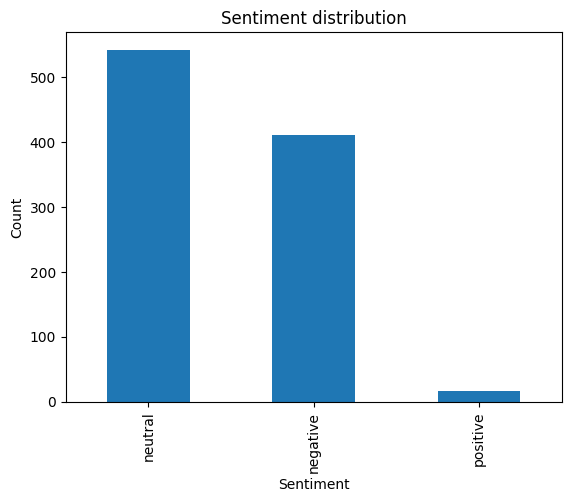

In [10]:
import matplotlib.pyplot as plt
 
# Visualize the distribution of sentiment classes
train_df['customer_sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

The training set is highly imbalanced. Neutral is the dominant class (542 samples), followed by negative (411), while positive is extremely underrepresented (17 samples). This imbalance is expected to make classification of the positive class difficult.

###  Coversation length analysis

In [ ]:
# Analyze the length of the conversations
train_df['text_length_words'] = train_df['conversation'].astype(str).apply(lambda x: len(x.split()))

train_df['text_length_words'].describe()

count    970.000000
mean     370.860825
std       98.267606
min        8.000000
25%      306.000000
50%      357.000000
75%      424.000000
max      992.000000
Name: text_length_words, dtype: float64

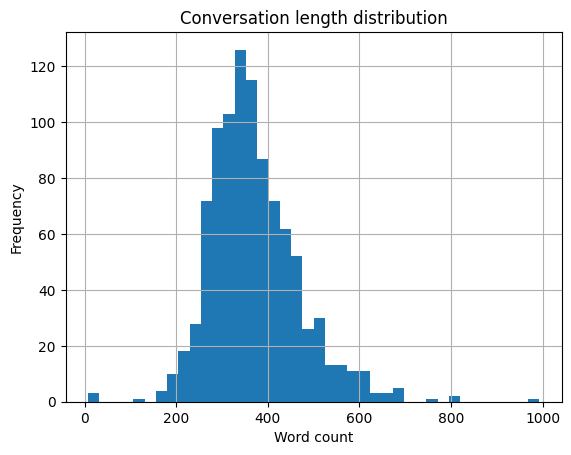

In [12]:
# Visualize the distribution of conversation lengths
train_df['text_length_words'].hist(bins=40)
plt.title("Conversation length distribution")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

Conversation lengths vary significantly, ranging from 8 to 992 words, with an average length of approximately 371 words. This indicates that sentiment is likely expressed across multiple dialogue turns rather than short statements. Because of the relatively long input texts, a transformer model is suitable for capturing contextual dependencies.

###  Conversation length vs sentiment

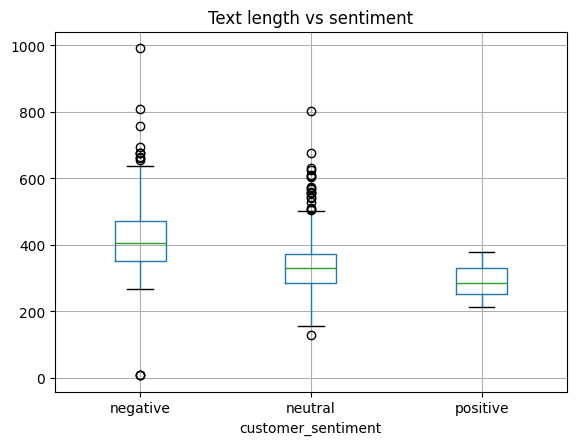

In [13]:
# Analyze the relationship between conversation length and sentiment
train_df.boxplot(column='text_length_words', by='customer_sentiment')
plt.title("Text length vs sentiment")
plt.suptitle("")
plt.show()

Negative conversations are generally longer than neutral and positive ones, suggesting that difficult or unresolved issues may require more dialogue. Positive conversations are the shortest on average, possibly indicating faster resolution.

### Issue complexity vs sentiment

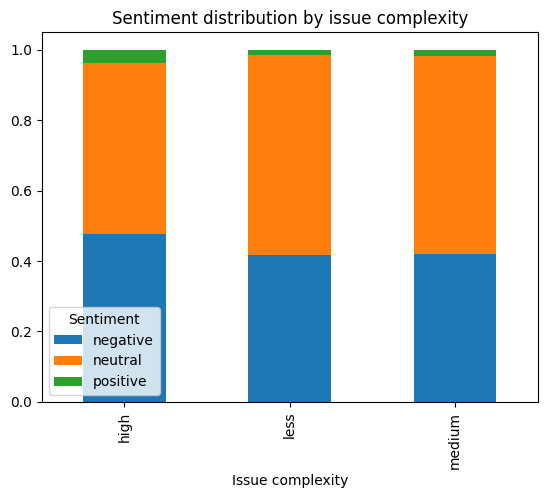

In [50]:
# Analyze the relationship between issue complexity and sentiment
pd.crosstab(
    train_df['issue_complexity'],
    train_df['customer_sentiment'],
    normalize='index'
).plot(kind='bar', stacked=True)
plt.title("Sentiment distribution by issue complexity")
plt.xlabel("Issue complexity")
plt.legend(title="Sentiment")


Issue complexity does not show a strong relationship with sentiment distribution. Negative and neutral sentiments appear in similar proportions across low, medium, and high complexity issues. This suggests that conversation content plays a more important role in sentiment classification than metadata features alone.

### Agent experience vs sentiment

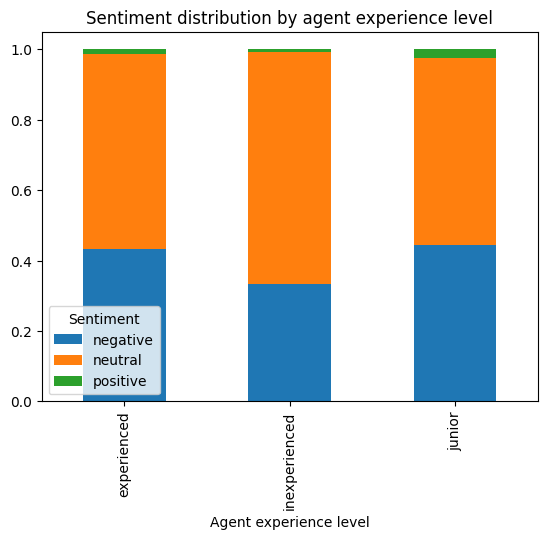

In [51]:
# Analyze the relationship between agent experience level and sentiment
pd.crosstab(
    train_df['agent_experience_level'],
    train_df['customer_sentiment'],
    normalize='index'
).plot(kind='bar', stacked=True)
plt.title("Sentiment distribution by agent experience level")
plt.xlabel("Agent experience level")
plt.legend(title="Sentiment")


Agent experience level does not show a clear correlation with sentiment distribution. Experienced agents do not consistently achieve more positive sentiment, possibly because they handle more complex or escalated cases. This suggests that conversation content is likely more informative than metadata alone.

### Issue category vs sentiment

In [55]:
# Count the number of samples for each issue category
issue_counts = train_df['issue_category'].value_counts()

# Analyze the relationship between issue category and sentiment
ct = pd.crosstab(
    train_df['issue_category'],
    train_df['customer_sentiment'],
    normalize='index'
)

ct['count'] = issue_counts
ct = ct.sort_values(by='count', ascending=False)
ct

customer_sentiment,negative,neutral,positive,count
issue_category,,,,
Return and Exchange,0.576087,0.423913,0.000000,92
Order Delivery Issues,1.000000,0.000000,0.000000,90
Pickup and Shipping,0.646154,0.353846,0.000000,65
Mobile Number and Email Verification,0.254237,0.745763,0.000000,59
Replacement and Return Process,0.192982,0.807018,0.000000,57
Returns and Refunds,0.783784,0.216216,0.000000,37
Invoice and Payment,0.527778,0.472222,0.000000,36
Pricing and Discounts,0.470588,0.529412,0.000000,34
Lost or Missing Warranty Card,0.322581,0.677419,0.000000,31


Issue category shows a clearer relationship with sentiment compared to other metadata features. Certain categories such as delivery issues and refunds are strongly associated with negative sentiment, while informational categories tend to be neutral. This indicates that the type of issue is an important factor influencing customer sentiment. However, some categories contain few samples, so extreme distributions should be interpreted with caution.

### Product category vs sentiment

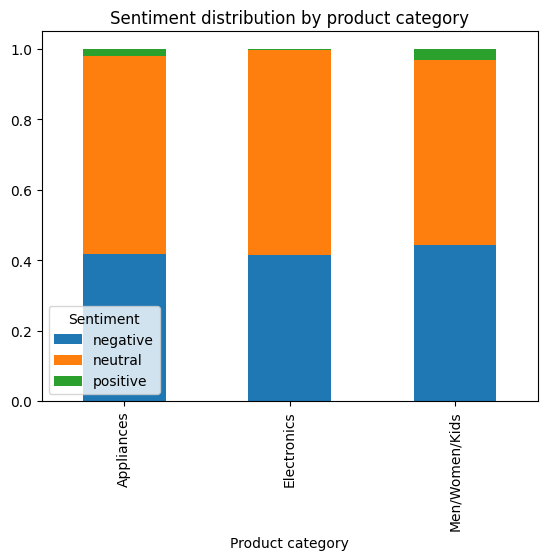

In [56]:
# Analyze the relationship between product category and sentiment
pd.crosstab(
    train_df['product_category'],
    train_df['customer_sentiment'],
    normalize='index'
).plot(kind='bar', stacked=True)
plt.title("Sentiment distribution by product category")
plt.xlabel("Product category")
plt.legend(title="Sentiment")

Product category shows relatively similar sentiment distributions, suggesting that customer sentiment is influenced more by the nature of the issue rather than the product type itself. 